# VPP Dispatch — Batch Dispatch & the FastAPI Service

This notebook covers two things:

1. **Batch dispatch** — solving several customers in parallel with `run_batch_dispatch`.
2. **Calling the API layer** — the same functionality exposed over HTTP by `src/vpp_dispatch/api.py`, exercised in-process with `TestClient` (no server needs to be running) and, optionally, over real HTTP if you start `uvicorn vpp_dispatch.api:app` yourself.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt

from src.vpp_dispatch.models.schemas import CustomerConfig
from src.vpp_dispatch.services.dispatch_service import run_batch_dispatch

## 1. Batch dispatch across several customers

In [2]:
def make_customer(customer_id, price_buy, load_kw):
    T = len(price_buy)
    return CustomerConfig(
        customer_id=customer_id,
        time_periods=T,
        assets=[
            {
                'asset_id': 'grid_1', 'asset_type': 'grid',
                'import_max_kw': 20, 'export_max_kw': 20,
                'price_buy': price_buy, 'price_sell': [0.05] * T,
            },
            {'asset_id': 'fixed_1', 'asset_type': 'fixed_load', 'fixed_load_profile_kw': load_kw},
        ],
    )

customers = [
    make_customer('flat_tariff', [0.25] * 6, [1, 1, 1, 1, 1, 1]),
    make_customer('tou_tariff', [0.4, 0.4, 0.1, 0.1, 0.4, 0.4], [1, 1, 1, 1, 1, 1]),
    make_customer('high_usage', [0.25] * 6, [3, 3, 3, 3, 3, 3]),
]

batch_results, overall_status = run_batch_dispatch(customers)
overall_status

{'total_customers': 3,
 'successful_customers': 3,
 'fallback_customers': 0,
 'failed_customers': 0,
 'overall_status': 'success',
 'total_objective': 7.8,
 'average_objective': 2.6,
 'asset_type_counts': {'GridAsset': 3, 'FixedLoadAsset': 3}}

In [3]:
for cid, r in batch_results.items():
    print(f"{cid}: objective={r['results']['objective']:.2f}, success={r['status']['success']}")

flat_tariff: objective=1.50, success=True
tou_tariff: objective=1.80, success=True
high_usage: objective=4.50, success=True


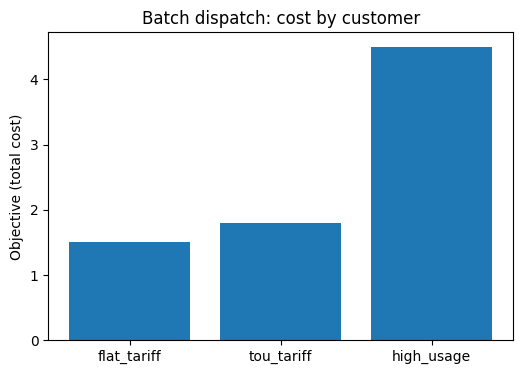

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(batch_results.keys(), [r['results']['objective'] for r in batch_results.values()])
ax.set_ylabel('Objective (total cost)')
ax.set_title('Batch dispatch: cost by customer')
plt.show()

## 2. Calling the FastAPI app in-process

`TestClient` drives the real FastAPI app object without needing a running server — useful for notebooks and CI.

In [5]:
from fastapi.testclient import TestClient
from src.vpp_dispatch.api import app

client = TestClient(app)

print(client.get('/').json())
print(client.get('/solvers').json())

INFO:httpx:HTTP Request: GET http://testserver/ "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET http://testserver/solvers "HTTP/1.1 200 OK"


{'service': 'VPP Dispatch API', 'status': 'ok', 'docs': '/docs', 'endpoints': ['/dispatch', '/dispatch/multi-asset', '/dispatch/batch', '/solvers', '/health']}
{'available': ['highs', 'glpk', 'cbc', 'gurobi', 'cplex'], 'primary': 'highs', 'fallback_order': ['highs', 'cbc', 'glpk']}


In [6]:
payload = {
    'customers': [c.model_dump() for c in customers]
}
resp = client.post('/dispatch/batch', json=payload)
print(resp.status_code)
resp.json()['overall_status']

INFO:src.vpp_dispatch.services.batch_dispatch:Starting batch dispatch for 3 customers with 4 workers
INFO:src.vpp_dispatch.services.dispatch_service:Running multi-asset dispatch for customer flat_tariff with 2 assets
INFO:src.vpp_dispatch.services.dispatch_service:Running multi-asset dispatch for customer tou_tariff with 2 assets
INFO:src.vpp_dispatch.services.dispatch_service:Running multi-asset dispatch for customer high_usage with 2 assets
INFO:src.vpp_dispatch.services.asset_factory:Created 2 out of 2 assets
INFO:src.vpp_dispatch.services.asset_factory:Created 2 out of 2 assets
INFO:src.vpp_dispatch.services.asset_factory:Created 2 out of 2 assets
INFO:src.vpp_dispatch.optimisation.model_builder:Model built successfully with 2 assets and 6 time periods
INFO:src.vpp_dispatch.optimisation.model_builder:Model built successfully with 2 assets and 6 time periods
INFO:src.vpp_dispatch.optimisation.model_builder:Model built successfully with 2 assets and 6 time periods
INFO:src.vpp_dispat

200


{'total_customers': 3,
 'successful_customers': 3,
 'fallback_customers': 0,
 'failed_customers': 0,
 'overall_status': 'success',
 'total_objective': 7.8,
 'average_objective': 2.6,
 'asset_type_counts': {'GridAsset': 3, 'FixedLoadAsset': 3}}

## 3. (Optional) Calling a real running server

If you've started the API separately, e.g.:

```bash
uvicorn vpp_dispatch.api:app --reload --port 8000
```

uncomment and run the cell below to hit it over real HTTP instead.

In [9]:
import requests
resp = requests.get('http://localhost:8000/health')
print(resp.json())

{'status': 'healthy'}
